In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import PowerTransformer

In [30]:
df=pd.read_csv("Titanic-Dataset.csv",usecols=["Age","Fare","Survived"])
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


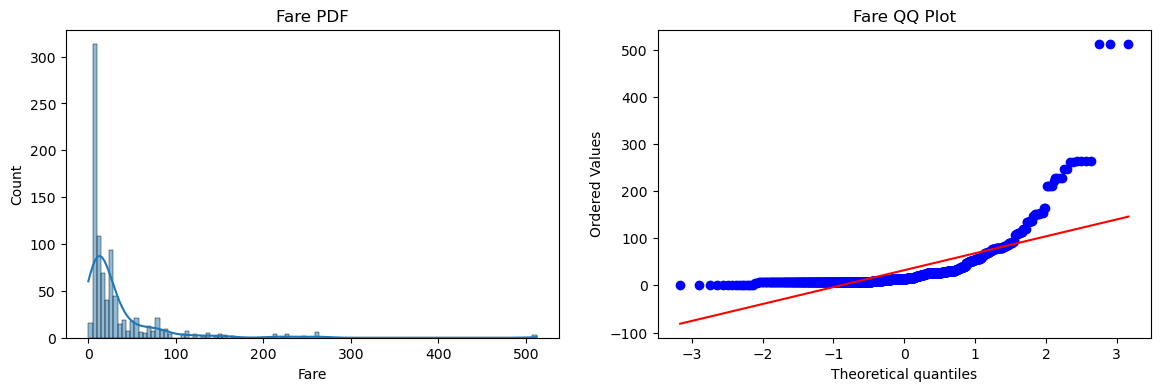

In [31]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
sns.histplot(df['Fare'], kde=True)
plt.title('Fare PDF')

plt.subplot(1,2,2)
stats.probplot(df['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [32]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [33]:
df.describe()

,Survived,Age,Fare
count,891.000000,714.000000,891.000000
mean,0.383838,29.699118,32.204208
std,0.486592,14.526497,49.693429
min,0.000000,0.420000,0.000000
25%,0.000000,20.125000,7.910400
50%,0.000000,28.000000,14.454200
75%,1.000000,38.000000,31.000000
max,1.000000,80.000000,512.329200


In [34]:
#removing the nan values from the age column using simple imputer 
imputer = SimpleImputer(strategy='most_frequent')
df['Age'] = imputer.fit_transform(df[['Age']])

#preparing the data for train and test
x=df.drop(columns=["Survived"])
y=df["Survived"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#training the model
pl=LinearRegression()
pl.fit(x_train,y_train)
y_pred=pl.predict(x_test)
r2_score(y_test,y_pred)

0.09463442376557052

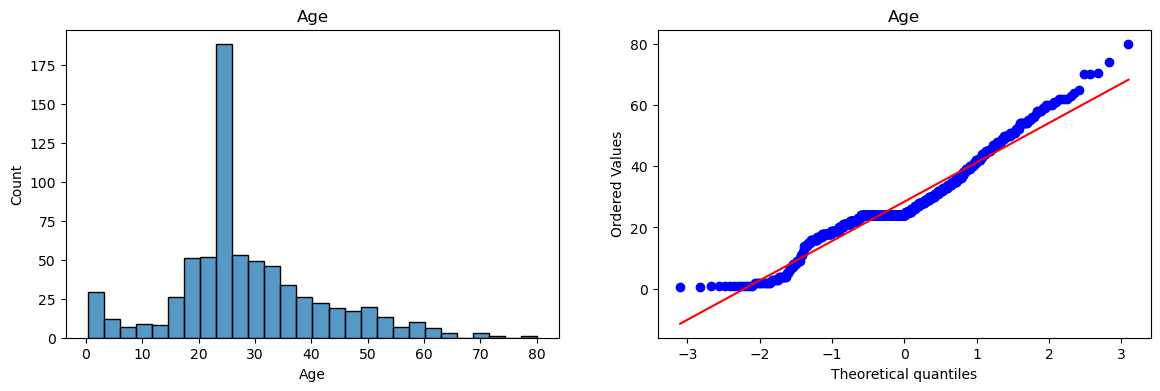

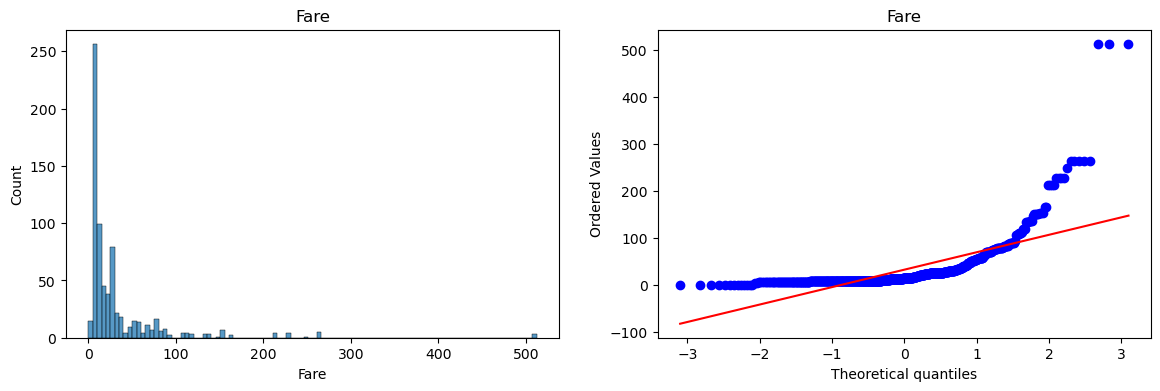

In [35]:
# Plotting the distplots without any transformation

for col in x_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(x_train[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()


In [36]:
# Applying Box-cox Transform

pt=PowerTransformer(method="box-cox")

# 0.00001 is added to make the value non-zero
x_train_transformed=pt.fit_transform(x_train+0.000001)
x_test_transformed=pt.fit_transform(x_test+0.000001)

# This lambda is used for the conservation
pd.DataFrame({"cols":x_train.columns,"box_cox_lamdas":pt.lambdas_})

,cols,box_cox_lamdas
0,Age,0.554592
1,Fare,0.233019


In [37]:
#training the model again after transform
pl=LinearRegression()
pl.fit(x_train_transformed,y_train)
y_pred2=pl.predict(x_test_transformed)
r2_score(y_test,y_pred2)

#We can see that the accuracy has been increase and little bit close to 1

0.1689724031508727

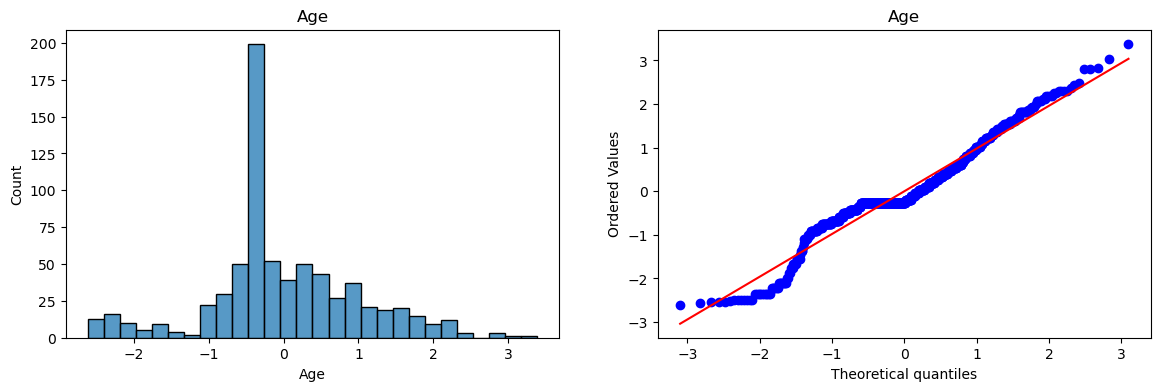

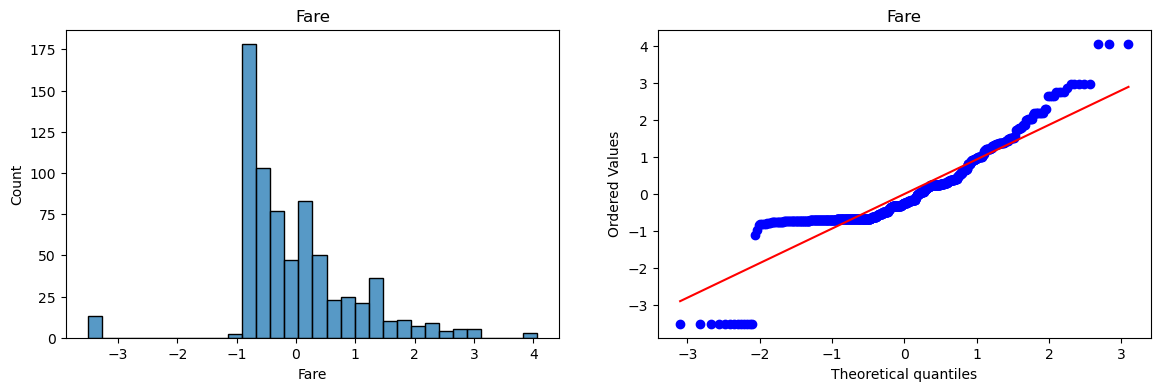

In [48]:
# Plotting the distplots without any transformation
# Before and after comparison for Box-Cox Plot
x_train_transformed = pd.DataFrame(x_train_transformed, columns=x_train.columns)
print()
for col in x_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(x_train_transformed[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train_transformed[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()


In [51]:
# Apply Yeo-Johnson transform
pt1 = PowerTransformer()

x_train_transformed2 = pt1.fit_transform(x_train)
x_test_transformed2 = pt1.transform(x_test)

lr = LinearRegression()
lr.fit(x_train_transformed2, y_train)

y_pred3 = lr.predict(x_test_transformed2)

print(r2_score(y_test, y_pred3))

pd.DataFrame({'cols':x_train.columns, 'Yeo_Johnson_lambdas':pt1.lambdas_})

#more improvement

0.17326567725127684


,cols,Yeo_Johnson_lambdas
0,Age,0.746885
1,Fare,-0.096641


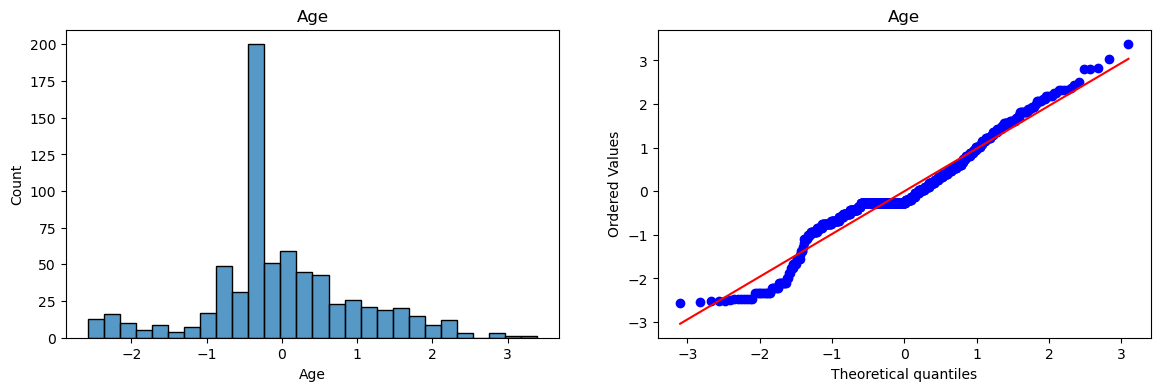

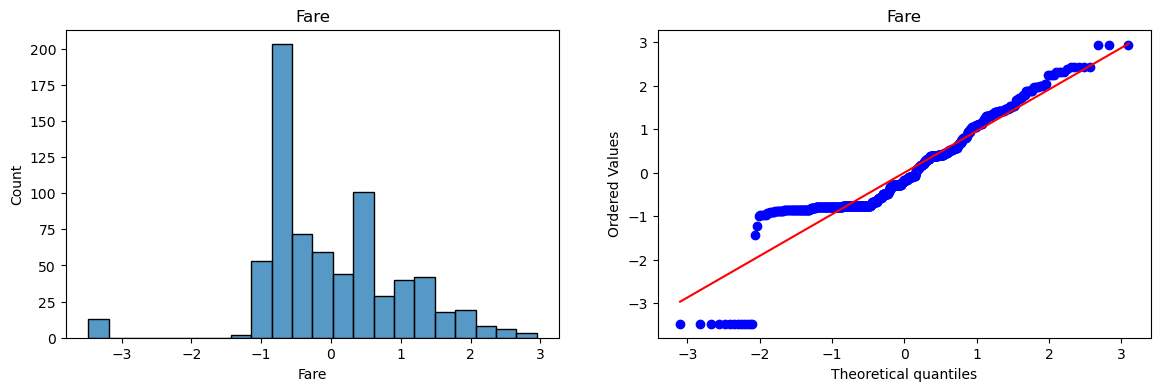

In [52]:
# Plotting the distplots without any transformation
# Before and after comparison for Box-Cox Plot
x_train_transformed2 = pd.DataFrame(x_train_transformed2, columns=x_train.columns)
print()
for col in x_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(x_train_transformed2[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train_transformed2[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()